In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [402]:
def coupled_osc(t_end, t_step, v_0, eps):
    len_t = int(t_end/t_step)
    t = np.linspace(0,t_end, len_t+1)
    v1 = np.zeros(len_t+1)
    v2 = np.zeros(len_t+1)
    
    v1[0] = v_0[0]
    v2[0] = v_0[1]

    spikes1 = [0]
    spikes2 = []

    for s in range(1,len(t)):
        if v1[s-1] >= 200:
            v1[s] = -200
            # keep track of spike time
            spikes1 = spikes1 + [t[s-1]]
        else: 
            dv1_dt = 1 + v1[s-1]**2 + eps*(v2[s-1] - v1[s-1])
            v1[s] = v1[s-1] + dv1_dt*t_step

        if v2[s-1] >= 200:
            v2[s] = -200
            # keep track of spike time
            spikes2 = spikes2 + [t[s-1]]
        else: 
            dv2_dt = 1 + v2[s-1]**2 + eps*(v1[s-1] - v2[s-1])
            v2[s] = v2[s-1] + dv2_dt*t_step
    # calculate lag times
    if len(spikes1) != len(spikes2):
        spikes1 = spikes1[:-1]
        print("Neuron 1 and Neuron 2 don't spike the same number of times", len(spikes1) - len(spikes2))
    lags = np.zeros(len(spikes1) - 1)
    for s in range(len(spikes1) - 1):
        lags[s] = (spikes2[s] - spikes1[s]) / (spikes1[s+1] - spikes1[s])
        
    return t, v1, v2, lags, spikes1[:-1]

In [229]:
v_0 = (-200, 1/np.tan(np.pi*.4))

In [404]:
t_test, v1_test, v2_test, lags, spike_times = coupled_osc(150, .0001, v_0, .02)

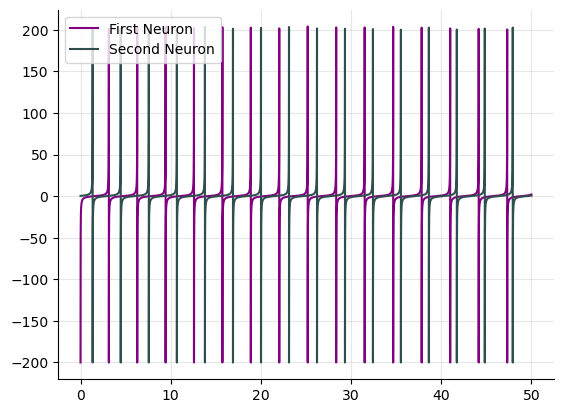

In [437]:
plt.plot(t_test[:500000], v1_test[:500000], label = "First Neuron",
        color = "purple")
plt.plot(t_test[:500000], v2_test[:500000], label = "Second Neuron",
        color = "darkslategrey")
plt.legend()
plt.grid(alpha = .3)
sns.despine()
plt.savefig("coupled_paths.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [259]:
# I gotta find the theoretical phase difference:

t_list = np.linspace(0,150, 200)
phase = [np.arctan(np.tan(np.pi*(.4)) * np.e**(-2*.02*t))/np.pi for t in t_list]

In [410]:
spike_times[1], spike_times[2]

(3.1431, 6.287800000000001)

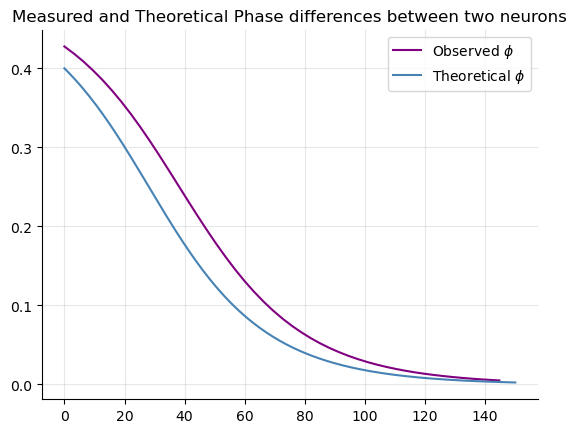

In [429]:
plt.plot(spike_times, lags, label = r"Observed $\phi$",
        color = "purple")
plt.plot(t_list, phase, label = r"Theoretical $\phi$",
        color = "steelblue")
plt.grid(alpha = .3)
plt.legend()
sns.despine()
plt.title("Measured and Theoretical Phase differences between two neurons")
plt.savefig("phase_dif.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [125]:
## Part ii) We can also fit the decay of tan(pi(phi(t)) for different values of epsilon

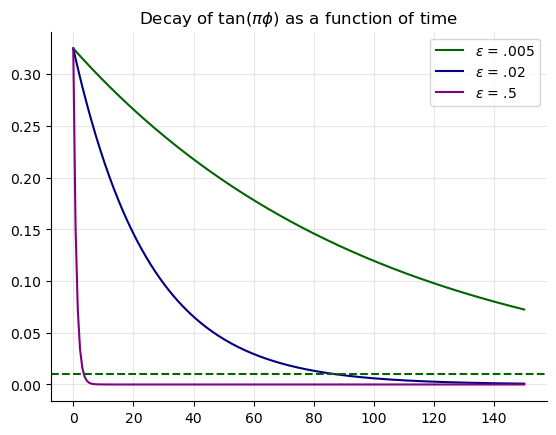

In [293]:
c = 1/np.tan(np.pi*.4)

phase1 = [c * np.e**(-2*.005*t) for t in t_list]
phase2 = [c * np.e**(-2*.02*t) for t in t_list]
phase3 = [c * np.e**(-2*.5*t) for t in t_list]


plt.plot(t_list, phase1, label = r"$\epsilon$ = .005", color = "darkgreen")
plt.plot(t_list, phase2, label = r"$\epsilon$ = .02", color = "navy")
plt.plot(t_list, phase3, label = r"$\epsilon$ = .5", color = "purple")
plt.axhline(y = .01, color = "darkgreen", linestyle = "--")
plt.axhline(y = .02, color = "darkgreen", linestyle = "--")
plt.axhline(y = 1, color = "darkgreen", linestyle = "--")

plt.legend()
plt.grid(alpha = .3)
sns.despine()
plt.title(r"Decay of $\tan(\pi \phi)$ as a function of time")
plt.show()

In [365]:
_, _, _, lags1, spike_times1 = coupled_osc(150, .0001, v_0, .005)
_, _, _, lags2, spike_times2 = coupled_osc(150, .0001, v_0, .02)
_, _, _, lags3, spike_times3 = coupled_osc(150, .0001, v_0, .05)

In [387]:
lags3

array([4.78308061e-01, 4.70633250e-01, 4.60367989e-01, 4.46495520e-01,
       4.28526159e-01, 4.04946148e-01, 3.74791503e-01, 3.38077622e-01,
       2.95176768e-01, 2.48875984e-01, 2.02549841e-01, 1.59721787e-01,
       1.22984061e-01, 9.31428211e-02, 6.97519929e-02, 5.18422221e-02,
       3.83723516e-02, 2.83096889e-02, 2.08558874e-02, 1.53272577e-02,
       1.12864658e-02, 8.29293187e-03, 6.09386466e-03, 4.46770488e-03,
       3.28747885e-03, 2.42594484e-03, 1.75578611e-03, 1.27701689e-03,
       9.25896363e-04, 7.02426564e-04, 5.10855683e-04, 3.51224496e-04,
       2.55444154e-04, 1.91583115e-04, 1.59652596e-04, 1.27722077e-04,
       9.57915576e-05, 6.38610384e-05, 3.19305192e-05, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [379]:
def decay_rate(x, t):
    d_list = np.zeros(len(x)-1)
    for i in range(len(x) - 1):
        d = -1 * np.log(x[i+1]/x[0])/t[i+1]
        d_list[i] = d

    return d_list

In [395]:
d_rate1 = decay_rate(lags1, spike_times1)
d_rate2 = decay_rate(lags2, spike_times2)
d_rate3 = decay_rate(lags3[:-8], spike_times3[:-8])

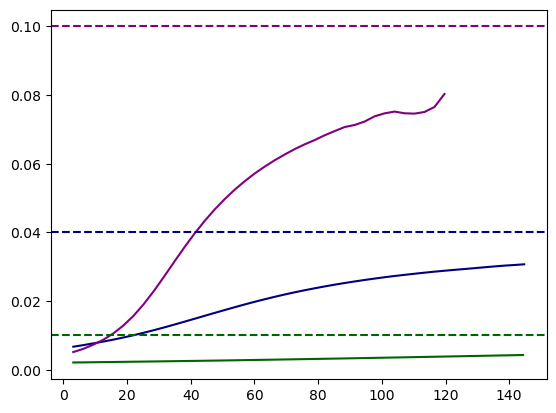

In [400]:
plt.plot(spike_times1[1:], d_rate1, color = "darkgreen")
plt.plot(spike_times2[1:], d_rate2, color = "navy")
plt.plot(spike_times3[1:-8], d_rate3, color = "purple")

plt.axhline(y = .005*2, color = "darkgreen", linestyle = "--")
plt.axhline(y = .02*2, color = "navy", linestyle = "--")
plt.axhline(y = .05*2, color = "purple", linestyle = "--")
plt.show()

In [441]:
np.polyfit(spike_times1, np.log(np.tan(np.pi*lags1)), 1)

array([-0.00967003,  1.19511244])

In [443]:
np.polyfit(spike_times2, np.log(np.tan(np.pi*lags2)), 1)

array([-0.03872918,  1.47891724])

In [445]:
np.polyfit(spike_times3[:32], np.log(np.tan(np.pi*lags3[:32])), 1)

array([-0.09636371,  2.72419985])

In [422]:
np.log(np.tan(np.pi*lags3)

array([1.46513864e+01, 1.08083553e+01, 7.99009046e+00, 5.89308375e+00,
       4.37841586e+00, 3.24859512e+00, 2.40974791e+00, 1.79325383e+00,
       1.33341653e+00, 9.92962418e-01, 7.38853489e-01, 5.48617008e-01,
       4.06813003e-01, 3.01264849e-01, 2.22708559e-01, 1.64322645e-01,
       1.21137673e-01, 8.91727501e-02, 6.56146233e-02, 4.81892499e-02,
       3.54723450e-02, 2.60589100e-02, 1.91467797e-02, 1.40366306e-02,
       1.03282866e-02, 7.62147806e-03, 5.51602070e-03, 4.01188840e-03,
       2.90879742e-03, 2.20674172e-03, 1.60490184e-03, 1.10340475e-03,
       8.02501648e-04, 6.01876180e-04, 5.01563465e-04, 4.01250760e-04,
       3.00938063e-04, 2.00625372e-04, 1.00312685e-04, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])